# 🔍 LSTM Модель для Детекції Фейкових Новин
Глибока модель на основі LSTM для класифікації новин як справжніх або фейкових

## 📦 Імпорт бібліотек

In [89]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(f'✅ PyTorch версія: {torch.__version__}')
print(f'✅ CUDA доступна: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'✅ GPU: {torch.cuda.get_device_name(0)}')

# Налаштування seed для відтворюваності
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n🖥️ Використовується: {device}')

✅ PyTorch версія: 2.5.1+cu121
✅ CUDA доступна: True
✅ GPU: NVIDIA GeForce RTX 3060 Laptop GPU

🖥️ Використовується: cuda


## 📊 Завантаження та аналіз даних

In [90]:
# Завантаження датасету
df = pd.read_csv('../../Datasets/full_dataset_detector.csv')
print(f"Розмір датасету: {df.shape}")
print(f"\nКолонки: {list(df.columns)}")
df.head()

Розмір датасету: (14119, 2)

Колонки: ['text', 'label']


,text,label
0,"Оголошення, які поширюють на під’їздах будинкі...",0.0
1,"РФ обстрілює Україну, а вибухонебезпечними пре...",0.0
2,"Російські медіа заявляють, мовляв, у країнах Є...",1.0
3,США змушують Україну звільнити Херсон до вибор...,1.0
4,українські військові прикриваються мирним насе...,1.0


In [91]:
# Базова статистика
print("Пропущені значення:")
print(df.isnull().sum())
print(f"\nРозподіл класів:")
print(df['label'].value_counts())
print(f"\nБаланс класів:")
print(df['label'].value_counts(normalize=True) * 100)

Пропущені значення:
text     0
label    1
dtype: int64

Розподіл класів:
label
0.0    7059
1.0    7059
Name: count, dtype: int64

Баланс класів:
label
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


In [92]:
# Очищення даних
df = df[['text', 'label']].dropna().copy()
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() > 10].copy()  # Видаляємо дуже короткі тексти

# Перевертаємо мітки: 0 -> FAKE, 1 -> TRUE
df['label'] = 1 - df['label'].astype(int)

print(f"Після очищення: {len(df)} записів")
print(f"\nРозподіл:")
print(f"TRUE (1): {(df['label'] == 1).sum()}")
print(f"FAKE (0): {(df['label'] == 0).sum()}")

df.head()

Після очищення: 14117 записів

Розподіл:
TRUE (1): 7059
FAKE (0): 7058


,text,label
0,"Оголошення, які поширюють на під’їздах будинкі...",1
1,"РФ обстрілює Україну, а вибухонебезпечними пре...",1
2,"Російські медіа заявляють, мовляв, у країнах Є...",0
3,США змушують Україну звільнити Херсон до вибор...,0
4,українські військові прикриваються мирним насе...,0


## 🧹 Preprocessing тексту

In [93]:
def clean_text(text):
    """Очищення тексту"""
    # Нижній регістр
    text = text.lower()
    # Видалення URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Видалення email
    text = re.sub(r'\S+@\S+', '', text)
    # Видалення HTML тегів
    text = re.sub(r'<.*?>', '', text)
    # Залишаємо тільки літери та пробіли
    text = re.sub(r'[^a-zA-Zа-яА-ЯіІїЇєЄґҐ\s]', ' ', text)
    # Видалення зайвих пробілів
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Застосовуємо очищення
tqdm.pandas(desc="Очищення текстів")
df['text_clean'] = df['text'].progress_apply(clean_text)

# Видаляємо порожні після очищення
df = df[df['text_clean'].str.len() > 0].copy()

print(f"\nПриклади очищених текстів:")
for i in range(3):
    print(f"\n{i+1}. Оригінал: {df.iloc[i]['text'][:100]}...")
    print(f"   Очищений: {df.iloc[i]['text_clean'][:100]}...")

Очищення текстів: 100%|██████████| 14117/14117 [00:00<00:00, 15681.06it/s]


Приклади очищених текстів:

1. Оригінал: Оголошення, які поширюють на під’їздах будинків, — не повістки, а наказ про загальну мобілізацію....
   Очищений: оголошення які поширюють на під їздах будинків не повістки а наказ про загальну мобілізацію...

2. Оригінал: РФ обстрілює Україну, а вибухонебезпечними предметами є не лише міни, а й різноманітні боєприпаси....
   Очищений: рф обстрілює україну а вибухонебезпечними предметами є не лише міни а й різноманітні боєприпаси...

3. Оригінал: Російські медіа заявляють, мовляв, у країнах ЄС збільшилася кількість випадків, коли українських біж...
   Очищений: російські медіа заявляють мовляв у країнах єс збільшилася кількість випадків коли українських біженц...


## 🔢 Tokenization та Padding

In [94]:
# Параметри токенізації (ПОКРАЩЕНІ)
MAX_WORDS = 50000  # ← Було 20000 - більше слів для кращої якості
MAX_LEN = 300      # ← Було 200 - більше контексту

# Створення токенізатора
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>', lower=True)
tokenizer.fit_on_texts(df['text_clean'])

# Перетворення текстів у послідовності
sequences = tokenizer.texts_to_sequences(df['text_clean'])

# Padding
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values

print(f"Розмір словника: {len(tokenizer.word_index)}")
print(f"Використовується слів: {min(MAX_WORDS, len(tokenizer.word_index))}")
print(f"\nФорма X: {X.shape}")
print(f"Форма y: {y.shape}")
print(f"\nПриклад послідовності:\n{X[0][:50]}...")

Розмір словника: 108521
Використовується слів: 50000

Форма X: (14117, 300)
Форма y: (14117,)

Приклад послідовності:
[ 2148    20  1310     3    26 19498  1070     9  1329    16  1889    11
  2629   589     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0]...


## 📂 Розділення на Train/Val/Test

In [95]:
# Спочатку відділяємо test set (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=SEED, stratify=y
)

# Потім ділимо temp на train та val (80%/10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=SEED, stratify=y_temp  # 0.111 * 0.9 ≈ 0.1
)

print(f"Train set: {X_train.shape[0]} зразків")
print(f"Validation set: {X_val.shape[0]} зразків")
print(f"Test set: {X_test.shape[0]} зразків")

print(f"\nРозподіл у train:")
print(f"TRUE: {(y_train == 1).sum()} | FAKE: {(y_train == 0).sum()}")
print(f"\nРозподіл у validation:")
print(f"TRUE: {(y_val == 1).sum()} | FAKE: {(y_val == 0).sum()}")
print(f"\nРозподіл у test:")
print(f"TRUE: {(y_test == 1).sum()} | FAKE: {(y_test == 0).sum()}")

Train set: 11294 зразків
Validation set: 1411 зразків
Test set: 1412 зразків

Розподіл у train:
TRUE: 5647 | FAKE: 5647

Розподіл у validation:
TRUE: 706 | FAKE: 705

Розподіл у test:
TRUE: 706 | FAKE: 706


## 🎯 Створення DataLoader

In [96]:
# Конвертація у тензори
train_data = TensorDataset(
    torch.LongTensor(X_train),
    torch.FloatTensor(y_train)
)
val_data = TensorDataset(
    torch.LongTensor(X_val),
    torch.FloatTensor(y_val)
)
test_data = TensorDataset(
    torch.LongTensor(X_test),
    torch.FloatTensor(y_test)
)

# DataLoader
BATCH_SIZE = 64

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoader створені")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

✅ DataLoader створені
Batch size: 64
Train batches: 177
Val batches: 23
Test batches: 23


## 🧠 Архітектура LSTM моделі з ATTENTION
Велика модель з багатошаровим LSTM, Attention, Dropout та Dense layers

In [97]:
class AttentionLayer(nn.Module):
    """Attention механізм для фокусу на важливих словах"""
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output):
        attention_weights = torch.softmax(self.attention(lstm_output), dim=1)
        context = torch.sum(attention_weights * lstm_output, dim=1)
        return context, attention_weights


class LSTMFakeDetector(nn.Module):
    def __init__(self, vocab_size, embedding_dim=200, hidden_dim=192,
                 num_layers=2, dropout=0.3):
        super(LSTMFakeDetector, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding_dropout = nn.Dropout(0.2)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        self.attention = AttentionLayer(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(hidden_dim * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

        self.ln1 = nn.LayerNorm(128)
        self.ln2 = nn.LayerNorm(64)

        self.relu = nn.ReLU()

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.embedding_dropout(embedded)

        lstm_out, _ = self.lstm(embedded)

        context, _ = self.attention(lstm_out)
        context = self.dropout(context)

        x = self.fc1(context)
        x = self.ln1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.ln2(x)
        x = self.relu(x)
        x = self.dropout(x)

        logits = self.fc3(x)
        return logits.squeeze(-1)


# Ініціалізація моделі (СТАБІЛЬНІ параметри)
VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index)) + 1
EMBEDDING_DIM = 200
HIDDEN_DIM = 192
NUM_LAYERS = 2
DROPOUT = 0.3

model = LSTMFakeDetector(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

print("\n" + "="*70)
print("🧠 STABLE LSTM + ATTENTION (LOGITS)")
print("="*70)
print(model)
print("="*70)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n📊 Загальна кількість параметрів: {total_params:,}")
print(f"📊 Тренувальних параметрів: {trainable_params:,}")
print(f"\n📦 Модель розміщена на: {device}")


🧠 STABLE LSTM + ATTENTION (LOGITS)
LSTMFakeDetector(
  (embedding): Embedding(50001, 200, padding_idx=0)
  (embedding_dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(200, 192, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Linear(in_features=384, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (relu): ReLU()
)

📊 Загальна кількість параметрів: 11,551,562
📊 Тренувальних параметрів: 11,551,562

📦 Модель розміщена на: cuda


## ⚙️ Налаштування тренування

In [98]:
# Loss та Optimizer
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Стабільніший scheduler для класифікації
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-6
)

print("✅ Оптимізатор: AdamW (lr=0.001)")
print("✅ Loss функція: BCEWithLogitsLoss")
print("✅ Scheduler: ReduceLROnPlateau (monitor=val_f1)")

✅ Оптимізатор: AdamW (lr=0.001)
✅ Loss функція: BCEWithLogitsLoss
✅ Scheduler: ReduceLROnPlateau (monitor=val_f1)


## 🏋️ Функції для тренування

In [99]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Тренування однієї епохи"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_x, batch_y in tqdm(dataloader, desc="Training", leave=False):
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        probs = torch.sigmoid(logits)
        predicted = (probs >= 0.5).float()
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    """Оцінка моделі"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in tqdm(dataloader, desc="Evaluating", leave=False):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            running_loss += loss.item()
            probs = torch.sigmoid(logits)
            predicted = (probs >= 0.5).float()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)

    return epoch_loss, accuracy, f1, precision, recall, all_preds, all_labels

print("✅ Функції тренування готові")

✅ Функції тренування готові


## 🚀 Тренування моделі

In [100]:
# Параметри тренування
NUM_EPOCHS = 20
PATIENCE = 5

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

best_val_f1 = 0.0
best_model_state = None
patience_counter = 0

print("\n" + "="*70)
print("🚀 ПОЧАТОК ТРЕНУВАННЯ (STABLE LOGITS TRAINING)")
print("="*70)

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*70}")
    print(f"Епоха {epoch + 1}/{NUM_EPOCHS}")
    print(f"{'='*70}")

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    val_loss, val_acc, val_f1, val_precision, val_recall, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_f1)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"\n📊 Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"📊 Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print(f"📊 Val F1: {val_f1:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f}")
    print(f"📊 Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print(f"\n✅ 🏆 НОВА НАЙКРАЩА МОДЕЛЬ! F1: {best_val_f1:.4f}")
    else:
        patience_counter += 1
        print(f"\n⏳ Без покращення: {patience_counter}/{PATIENCE} епох")

    if patience_counter >= PATIENCE:
        print(f"\n🛑 EARLY STOPPING: Немає покращення {PATIENCE} епох підряд")
        print(f"🛑 Зупинка на епосі {epoch + 1}/{NUM_EPOCHS}")
        break

print("\n" + "="*70)
print("🎉 ТРЕНУВАННЯ ЗАВЕРШЕНО!")
print("="*70)
print(f"✅ Найкращий Val F1-score: {best_val_f1:.4f}")
print(f"✅ Навчалося епох: {len(history['val_f1'])}")

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model.to(device)
    print("✅ Завантажено найкращу модель")


🚀 ПОЧАТОК ТРЕНУВАННЯ (STABLE LOGITS TRAINING)

Епоха 1/20



📊 Train Loss: 0.6716 | Train Acc: 0.5692
📊 Val Loss: 0.5844 | Val Acc: 0.7165
📊 Val F1: 0.7187 | Precision: 0.7137 | Recall: 0.7238
📊 Learning Rate: 0.001000

✅ 🏆 НОВА НАЙКРАЩА МОДЕЛЬ! F1: 0.7187

Епоха 2/20



📊 Train Loss: 0.5683 | Train Acc: 0.7275
📊 Val Loss: 0.5840 | Val Acc: 0.7300
📊 Val F1: 0.7550 | Precision: 0.6914 | Recall: 0.8314
📊 Learning Rate: 0.001000

✅ 🏆 НОВА НАЙКРАЩА МОДЕЛЬ! F1: 0.7550

Епоха 3/20



📊 Train Loss: 0.5110 | Train Acc: 0.7642
📊 Val Loss: 0.4682 | Val Acc: 0.7845
📊 Val F1: 0.7862 | Precision: 0.7807 | Recall: 0.7918
📊 Learning Rate: 0.001000

✅ 🏆 НОВА НАЙКРАЩА МОДЕЛЬ! F1: 0.7862

Епоха 4/20



📊 Train Loss: 0.3980 | Train Acc: 0.8324
📊 Val Loss: 0.4569 | Val Acc: 0.8016
📊 Val F1: 0.7977 | Precision: 0.8142 | Recall: 0.7819
📊 Learning Rate: 0.001000

✅ 🏆 НОВА НАЙКРАЩА МОДЕЛЬ! F1: 0.7977

Епоха 5/20


...


📊 Train Loss: 0.0263 | Train Acc: 0.9926
📊 Val Loss: 0.7957 | Val Acc: 0.8469
📊 Val F1: 0.8502 | Precision: 0.8329 | Recall: 0.8683
📊 Learning Rate: 0.000500

✅ 🏆 НОВА НАЙКРАЩА МОДЕЛЬ! F1: 0.8502

Епоха 17/20



📊 Train Loss: 0.0221 | Train Acc: 0.9939
📊 Val Loss: 0.8049 | Val Acc: 0.8370
📊 Val F1: 0.8378 | Precision: 0.8343 | Recall: 0.8414
📊 Learning Rate: 0.000500

⏳ Без покращення: 1/5 епох

Епоха 18/20



📊 Train Loss: 0.0202 | Train Acc: 0.9945
📊 Val Loss: 0.8612 | Val Acc: 0.8434
📊 Val F1: 0.8449 | Precision: 0.8373 | Recall: 0.8527
📊 Learning Rate: 0.000500

⏳ Без покращення: 2/5 епох

Епоха 19/20



📊 Train Loss: 0.0193 | Train Acc: 0.9944
📊 Val Loss: 0.8561 | Val Acc: 0.8441
📊 Val F1: 0.8493 | Precision: 0.8223 | Recall: 0.8782
📊 Learning Rate: 0.000250

⏳ Без покращення: 3/5 епох

Епоха 20/20



📊 Train Loss: 0.0116 | Train Acc: 0.9972
📊 Val Loss: 0.9418 | Val Acc: 0.8462
📊 Val F1: 0.8498 | Precision: 0.8309 | Recall: 0.8697
📊 Learning Rate: 0.000250

⏳ Без покращення: 4/5 епох

🎉 ТРЕНУВАННЯ ЗАВЕРШЕНО!
✅ Найкращий Val F1-score: 0.8502
✅ Навчалося епох: 20
✅ Завантажено найкращу модель


## 📈 Візуалізація навчання

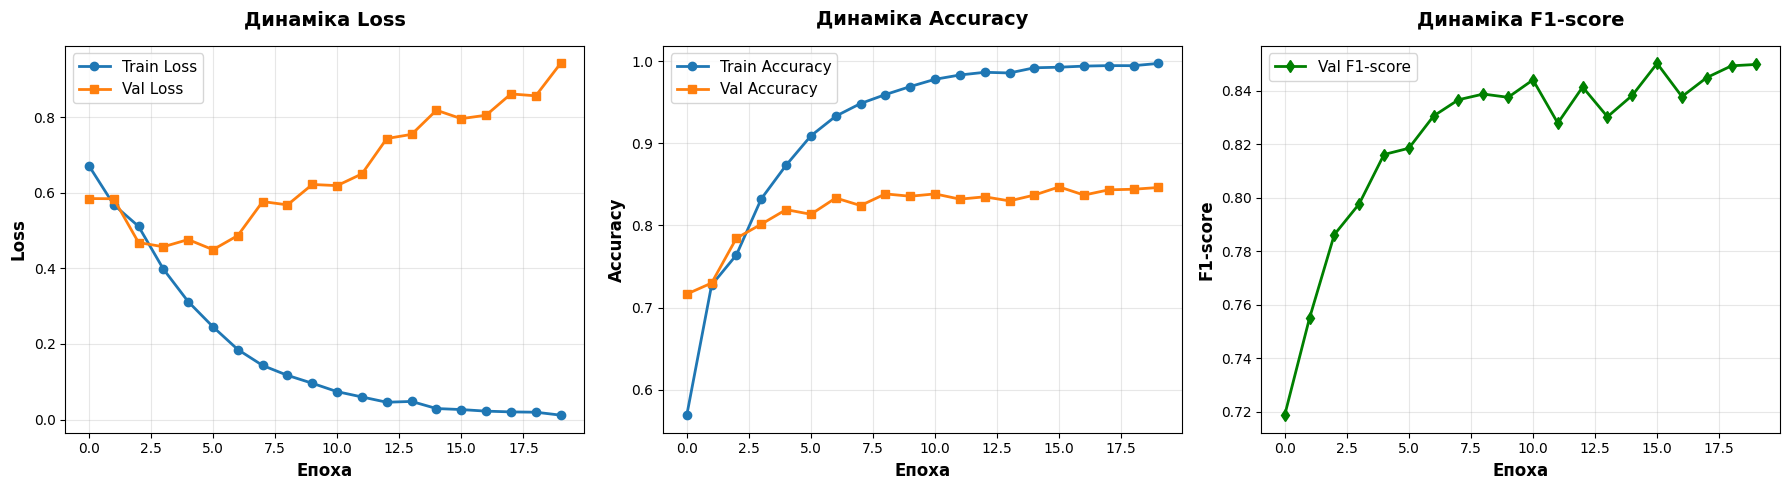

In [101]:
# Графік Loss
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Епоха', fontsize=12, weight='bold')
axes[0].set_ylabel('Loss', fontsize=12, weight='bold')
axes[0].set_title('Динаміка Loss', fontsize=14, weight='bold', pad=15)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Епоха', fontsize=12, weight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, weight='bold')
axes[1].set_title('Динаміка Accuracy', fontsize=14, weight='bold', pad=15)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

# F1-score
axes[2].plot(history['val_f1'], label='Val F1-score', marker='d', linewidth=2, color='green')
axes[2].set_xlabel('Епоха', fontsize=12, weight='bold')
axes[2].set_ylabel('F1-score', fontsize=12, weight='bold')
axes[2].set_title('Динаміка F1-score', fontsize=14, weight='bold', pad=15)
axes[2].legend(fontsize=11)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 🎯 Оцінка на тестовому наборі

In [102]:
# Оцінка на тестовому наборі
test_loss, test_acc, test_f1, test_precision, test_recall, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

print("\n" + "="*70)
print("📊 РЕЗУЛЬТАТИ НА ТЕСТОВОМУ НАБОРІ")
print("="*70)
print(f"\n🎯 Test Loss: {test_loss:.4f}")
print(f"🎯 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"🎯 Test F1-score: {test_f1:.4f}")
print(f"🎯 Test Precision: {test_precision:.4f}")
print(f"🎯 Test Recall: {test_recall:.4f}")
print("="*70)


📊 РЕЗУЛЬТАТИ НА ТЕСТОВОМУ НАБОРІ

🎯 Test Loss: 0.6785
🎯 Test Accuracy: 0.8357 (83.57%)
🎯 Test F1-score: 0.8375
🎯 Test Precision: 0.8283
🎯 Test Recall: 0.8470


## 📋 Classification Report

In [103]:
# Детальний classification report
print("\n" + "="*70)
print("📋 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=['FAKE (0)', 'TRUE (1)'],
    digits=4
))
print("="*70)


📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    FAKE (0)     0.8435    0.8244    0.8338       706
    TRUE (1)     0.8283    0.8470    0.8375       706

    accuracy                         0.8357      1412
   macro avg     0.8359    0.8357    0.8357      1412
weighted avg     0.8359    0.8357    0.8357      1412



## 🔥 Confusion Matrix

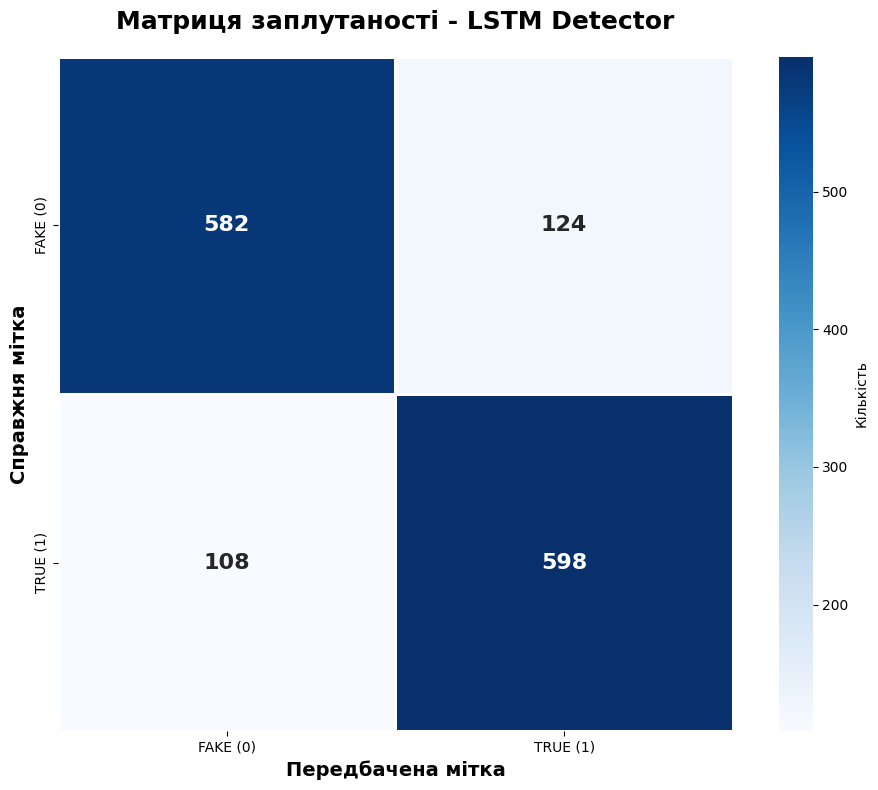


📊 СТАТИСТИКА ПО КЛАСАХ
FAKE (0)     | Правильно:   582 /   706 | Точність: 82.44%
TRUE (1)     | Правильно:   598 /   706 | Точність: 84.70%


In [104]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['FAKE (0)', 'TRUE (1)'],
    yticklabels=['FAKE (0)', 'TRUE (1)'],
    cbar_kws={'label': 'Кількість'},
    annot_kws={'size': 16, 'weight': 'bold'},
    square=True,
    linewidths=2,
    linecolor='white'
)
plt.title('Матриця заплутаності - LSTM Detector', fontsize=18, weight='bold', pad=20)
plt.ylabel('Справжня мітка', fontsize=14, weight='bold')
plt.xlabel('Передбачена мітка', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# Статистика по класах
print("\n" + "="*70)
print("📊 СТАТИСТИКА ПО КЛАСАХ")
print("="*70)
for i, label in enumerate(['FAKE (0)', 'TRUE (1)']):
    correct = cm[i][i]
    total = cm[i].sum()
    accuracy = correct / total * 100 if total > 0 else 0
    print(f"{label:12} | Правильно: {correct:5} / {total:5} | Точність: {accuracy:.2f}%")
print("="*70)

## 📊 ROC Curve та AUC

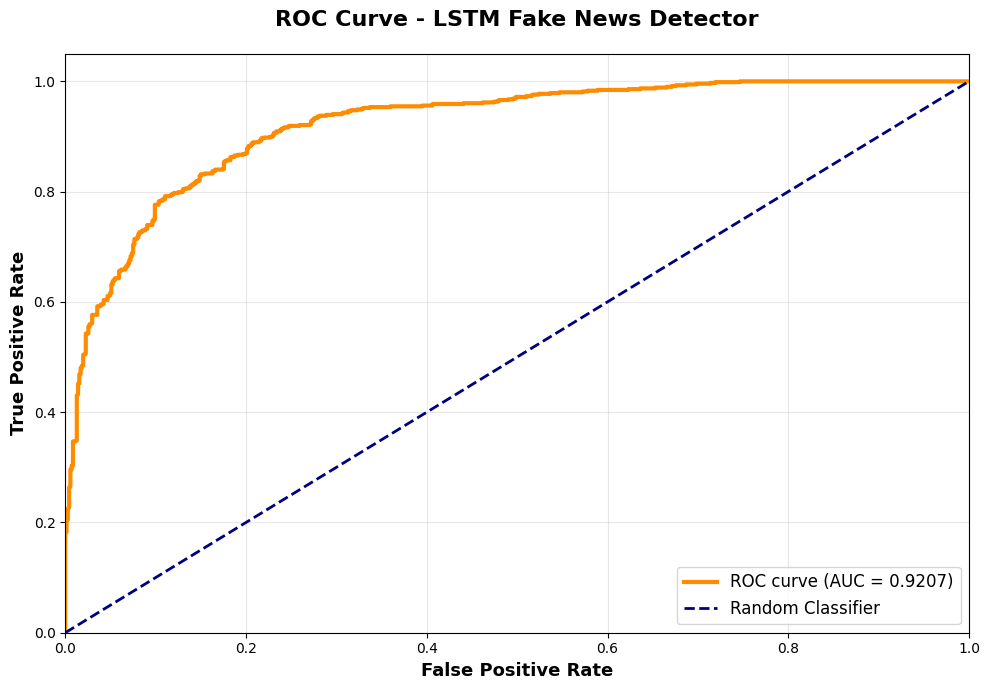


🎯 AUC Score: 0.9207


In [105]:
# Отримання probability scores
model.eval()
all_probs = []
all_labels_roc = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        logits = model(batch_x)
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy())
        all_labels_roc.extend(batch_y.numpy())

# ROC curve
fpr, tpr, thresholds = roc_curve(all_labels_roc, all_probs)
roc_auc = auc(fpr, tpr)

# Візуалізація
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, weight='bold')
plt.ylabel('True Positive Rate', fontsize=13, weight='bold')
plt.title('ROC Curve - LSTM Fake News Detector', fontsize=16, weight='bold', pad=20)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n🎯 AUC Score: {roc_auc:.4f}")

## 🔮 Функція передбачення для нових текстів

In [106]:
def predict_news(text, model, tokenizer, max_len=MAX_LEN, device=device):
    """
    Передбачення для нового тексту

    Args:
        text (str): Текст новини для перевірки
        model: LSTM модель
        tokenizer: Keras Tokenizer
        max_len (int): Максимальна довжина послідовності
        device: CPU або GPU

    Returns:
        dict: Словник з результатами передбачення
    """
    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')

    input_tensor = torch.LongTensor(padded).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        prob = torch.sigmoid(logits).item()

    prediction = 1 if prob > 0.5 else 0
    label = 'TRUE' if prediction == 1 else 'FAKE'
    confidence = prob if prediction == 1 else 1 - prob

    result = {
        'text': text[:100] + '...' if len(text) > 100 else text,
        'prediction': label,
        'confidence': confidence * 100,
        'probability_true': prob * 100,
        'probability_fake': (1 - prob) * 100
    }

    return result


def print_prediction(result):
    """Красиве виведення результату"""
    print("\n" + "="*70)
    print("🔮 РЕЗУЛЬТАТ ПЕРЕДБАЧЕННЯ")
    print("="*70)
    print(f"\n📰 Текст: {result['text']}")
    print(f"\n🎯 Передбачення: {result['prediction']}")
    print(f"✅ Впевненість: {result['confidence']:.2f}%")
    print(f"\n📊 Ймовірності:")
    print(f"   TRUE: {result['probability_true']:.2f}%")
    print(f"   FAKE: {result['probability_fake']:.2f}%")
    print("="*70)

print("✅ Функція передбачення готова!")

✅ Функція передбачення готова!


## 🧪 Тестування на прикладах

In [117]:
# Приклад 1: Реальна новина
sample_text_1 = """Уряд оголосив про нові економічні реформи, спрямовані на зниження інфляції та стимулювання зростання. Міністр фінансів представив бюджет на засіданні парламенту.."""

result1 = predict_news(sample_text_1, model, tokenizer)
print_prediction(result1)


🔮 РЕЗУЛЬТАТ ПЕРЕДБАЧЕННЯ

📰 Текст: Уряд оголосив про нові економічні реформи, спрямовані на зниження інфляції та стимулювання зростання...

🎯 Передбачення: TRUE
✅ Впевненість: 98.79%

📊 Ймовірності:
   TRUE: 98.79%
   FAKE: 1.21%


In [118]:
# Приклад 2: Підозріла новина
sample_text_2 = """ТЕРМІНОВО: Вчені виявили інопланетян, які живуть під землею! Уряд приховує правду від громадян! Натисніть тут, щоб дізнатися шокуючі подробиці!"""

result2 = predict_news(sample_text_2, model, tokenizer)
print_prediction(result2)


🔮 РЕЗУЛЬТАТ ПЕРЕДБАЧЕННЯ

📰 Текст: ТЕРМІНОВО: Вчені виявили інопланетян, які живуть під землею! Уряд приховує правду від громадян! Нати...

🎯 Передбачення: FAKE
✅ Впевненість: 99.94%

📊 Ймовірності:
   TRUE: 0.06%
   FAKE: 99.94%


In [109]:
# Приклад 3: Нейтральна новина
sample_text_3 = """Війна закінчиться у 23134 році заявив президент польщі барак обама"""

result3 = predict_news(sample_text_3, model, tokenizer)
print_prediction(result3)


🔮 РЕЗУЛЬТАТ ПЕРЕДБАЧЕННЯ

📰 Текст: Війна закінчиться у 23134 році заявив президент польщі барак обама

🎯 Передбачення: FAKE
✅ Впевненість: 99.50%

📊 Ймовірності:
   TRUE: 0.50%
   FAKE: 99.50%


## 💾 Збереження моделі та токенізатора

In [110]:
# Збереження PyTorch моделі
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab_size': VOCAB_SIZE,
    'embedding_dim': EMBEDDING_DIM,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'max_len': MAX_LEN,
    'test_accuracy': test_acc,
    'test_f1': test_f1
}, 'lstm_fake_detector.pth')

# Збереження токенізатора
with open('lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Збереження історії тренування
with open('lstm_training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

print("\n" + "="*70)
print("💾 ЗБЕРЕЖЕННЯ ЗАВЕРШЕНО")
print("="*70)
print("✅ lstm_fake_detector.pth - модель")
print("✅ lstm_tokenizer.pkl - токенізатор")
print("✅ lstm_training_history.pkl - історія тренування")
print("="*70)


💾 ЗБЕРЕЖЕННЯ ЗАВЕРШЕНО
✅ lstm_fake_detector.pth - модель
✅ lstm_tokenizer.pkl - токенізатор
✅ lstm_training_history.pkl - історія тренування


## 📝 Підсумкова статистика

In [111]:
print("\n" + "="*70)
print("📊 ПІДСУМКОВА СТАТИСТИКА LSTM МОДЕЛІ")
print("="*70)

summary_data = {
    'Параметр': [
        'Архітектура',
        'Кількість параметрів',
        'Розмір словника',
        'Embedding розмірність',
        'Hidden розмірність',
        'Кількість LSTM шарів',
        'Bidirectional',
        'Dropout',
        'Max sequence length',
        'Batch size',
        'Епох навчання',
        '',
        'Test Accuracy',
        'Test F1-score',
        'Test Precision',
        'Test Recall',
        'AUC Score',
        '',
        'Кращий Val F1',
        'Фінальний Train Loss',
        'Фінальний Val Loss'
    ],
    'Значення': [
        f'LSTM ({NUM_LAYERS} layers) + Attention',
        f"{total_params:,}",
        f"{VOCAB_SIZE:,}",
        EMBEDDING_DIM,
        HIDDEN_DIM,
        NUM_LAYERS,
        'Так',
        DROPOUT,
        MAX_LEN,
        BATCH_SIZE,
        NUM_EPOCHS,
        '',
        f"{test_acc:.4f} ({test_acc*100:.2f}%)",
        f"{test_f1:.4f}",
        f"{test_precision:.4f}",
        f"{test_recall:.4f}",
        f"{roc_auc:.4f}",
        '',
        f"{best_val_f1:.4f}",
        f"{history['train_loss'][-1]:.4f}",
        f"{history['val_loss'][-1]:.4f}"
    ]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print("="*70)
print("\n🎉 Аналіз завершено! Модель готова до використання.")
print("="*70)


📊 ПІДСУМКОВА СТАТИСТИКА LSTM МОДЕЛІ
             Параметр                    Значення
          Архітектура LSTM (2 layers) + Attention
 Кількість параметрів                  11,551,562
      Розмір словника                      50,001
Embedding розмірність                         200
   Hidden розмірність                         192
 Кількість LSTM шарів                           2
        Bidirectional                         Так
              Dropout                         0.3
  Max sequence length                         300
           Batch size                          64
        Епох навчання                          20
                                                 
        Test Accuracy             0.8357 (83.57%)
        Test F1-score                      0.8375
       Test Precision                      0.8283
          Test Recall                      0.8470
            AUC Score                      0.9207
                                                 
        Кращи